# Célula 1: Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

con = duckdb.connect()
data_path = r"C:\projetos\selecao-br\data"

con.execute(f"""
    CREATE OR REPLACE VIEW results AS
    SELECT * FROM read_csv_auto(
        '{data_path}/results.csv',
        nullstr='NA',
        types={{'home_score': 'INTEGER', 'away_score': 'INTEGER'}}
    );
    CREATE OR REPLACE VIEW goalscorers AS
    SELECT * FROM read_csv_auto('{data_path}/goalscorers.csv');
""")
print("Pronto!")

Pronto!


# Célula 2: Aproveitamento por Década

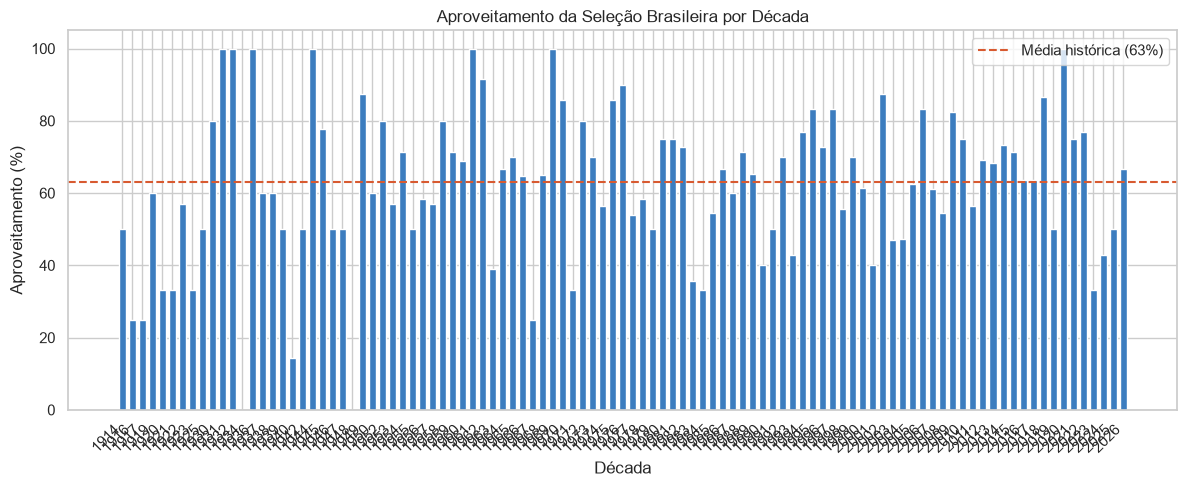

In [2]:
df_decada = con.execute("""
    SELECT
        CAST((YEAR(date) / 10) * 10 AS INTEGER) AS decada,
        COUNT(*) AS jogos,
        ROUND(100.0 * SUM(CASE
            WHEN (home_team = 'Brazil' AND home_score > away_score)
              OR (away_team = 'Brazil' AND away_score > home_score) THEN 1 ELSE 0
        END) / COUNT(*), 1) AS aproveitamento_pct
    FROM results
    WHERE (home_team = 'Brazil' OR away_team = 'Brazil')
      AND home_score IS NOT NULL
    GROUP BY decada
    ORDER BY decada
""").fetchdf()

plt.figure()
bars = plt.bar(df_decada["decada"].astype(str), df_decada["aproveitamento_pct"],
               color="#3C7DBF", edgecolor="white", width=0.7)
plt.axhline(y=63, color="#D85A30", linestyle="--", linewidth=1.5, label="Média histórica (63%)")
plt.title("Aproveitamento da Seleção Brasileira por Década")
plt.xlabel("Década")
plt.ylabel("Aproveitamento (%)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\projetos\selecao-br\docs\aproveitamento_decada.png", dpi=150)
plt.show()

# Célula 3: Histórico contra os 10 maiores rivais

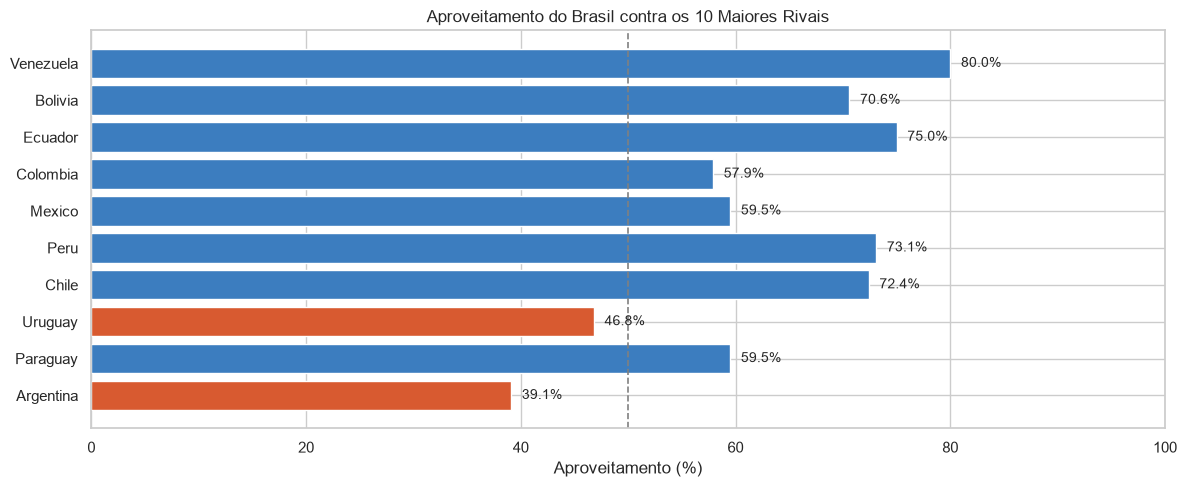

In [3]:
df_rivais = con.execute("""
    SELECT
        CASE WHEN home_team = 'Brazil' THEN away_team ELSE home_team END AS adversario,
        COUNT(*) AS jogos,
        ROUND(100.0 * SUM(CASE
            WHEN (home_team = 'Brazil' AND home_score > away_score)
              OR (away_team = 'Brazil' AND away_score > home_score) THEN 1 ELSE 0
        END) / COUNT(*), 1) AS aproveitamento_pct
    FROM results
    WHERE (home_team = 'Brazil' OR away_team = 'Brazil')
      AND home_score IS NOT NULL
    GROUP BY adversario
    HAVING COUNT(*) >= 20
    ORDER BY jogos DESC
    LIMIT 10
""").fetchdf()

colors = ["#D85A30" if x < 50 else "#3C7DBF" for x in df_rivais["aproveitamento_pct"]]

plt.figure()
bars = plt.barh(df_rivais["adversario"], df_rivais["aproveitamento_pct"],
                color=colors, edgecolor="white")
plt.axvline(x=50, color="gray", linestyle="--", linewidth=1.2)
plt.title("Aproveitamento do Brasil contra os 10 Maiores Rivais")
plt.xlabel("Aproveitamento (%)")
plt.xlim(0, 100)
for bar, val in zip(bars, df_rivais["aproveitamento_pct"]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(r"C:\projetos\selecao-br\docs\aproveitamento_rivais.png", dpi=150)
plt.show()

# Célula 4: Gols marcados x sofridos por década

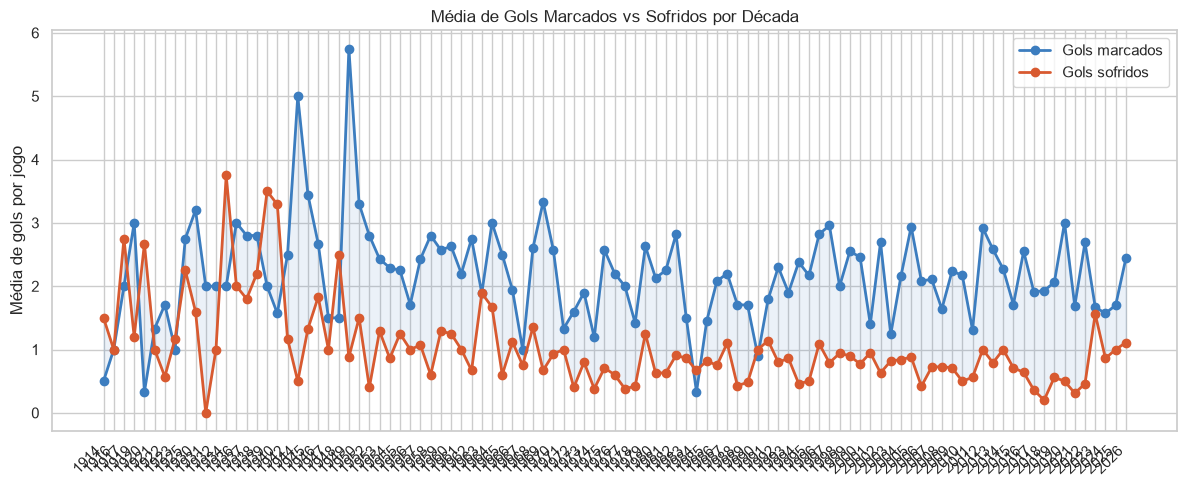

In [4]:
df_gols = con.execute("""
    SELECT
        CAST((YEAR(date) / 10) * 10 AS INTEGER) AS decada,
        ROUND(AVG(CASE WHEN home_team = 'Brazil' THEN home_score ELSE away_score END), 2) AS media_marcados,
        ROUND(AVG(CASE WHEN home_team = 'Brazil' THEN away_score ELSE home_score END), 2) AS media_sofridos
    FROM results
    WHERE (home_team = 'Brazil' OR away_team = 'Brazil')
      AND home_score IS NOT NULL
    GROUP BY decada
    ORDER BY decada
""").fetchdf()

x = df_gols["decada"].astype(str)
plt.figure()
plt.plot(x, df_gols["media_marcados"], marker="o", color="#3C7DBF",
         linewidth=2, label="Gols marcados")
plt.plot(x, df_gols["media_sofridos"], marker="o", color="#D85A30",
         linewidth=2, label="Gols sofridos")
plt.fill_between(range(len(x)), df_gols["media_marcados"],
                 df_gols["media_sofridos"], alpha=0.1, color="#3C7DBF")
plt.xticks(range(len(x)), x, rotation=45, ha="right")
plt.title("Média de Gols Marcados vs Sofridos por Década")
plt.ylabel("Média de gols por jogo")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\projetos\selecao-br\docs\gols_decada.png", dpi=150)
plt.show()

# Célula 5: Top 10 artilheiros da seleção

C:\Users\danil\AppData\Local\Temp\ipykernel_48028\2616946679.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_artilheiros, x="gols", y="jogador", palette="Blues_r")


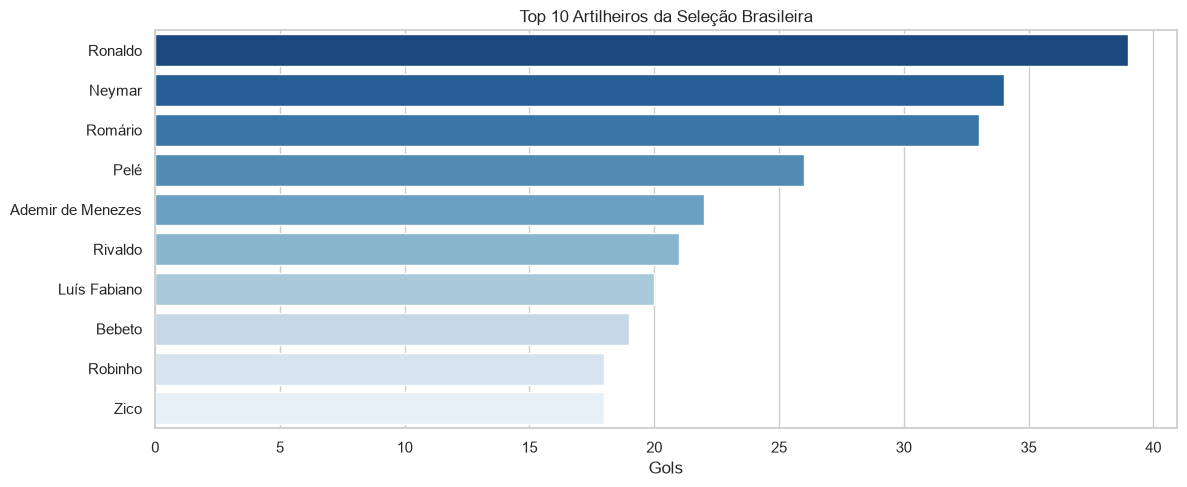

In [5]:
df_artilheiros = con.execute("""
    SELECT
        scorer AS jogador,
        COUNT(*) AS gols
    FROM goalscorers
    WHERE team = 'Brazil'
      AND own_goal = False
    GROUP BY jogador
    ORDER BY gols DESC
    LIMIT 10
""").fetchdf()

plt.figure()
sns.barplot(data=df_artilheiros, x="gols", y="jogador", palette="Blues_r")
plt.title("Top 10 Artilheiros da Seleção Brasileira")
plt.xlabel("Gols")
plt.ylabel("")
plt.tight_layout()
plt.savefig(r"C:\projetos\selecao-br\docs\artilheiros.png", dpi=150)
plt.show()

# Célula 7: Exportar dataset tratado para o PowerBI


In [6]:
df_final = con.execute("""
    SELECT
        r.date,
        YEAR(r.date) AS ano,
        CAST((YEAR(r.date) / 10) * 10 AS INTEGER) AS decada,
        r.home_team,
        r.away_team,
        r.home_score,
        r.away_score,
        r.tournament,
        r.city,
        r.country,
        r.neutral,
        CASE WHEN home_team = 'Brazil' THEN away_team ELSE home_team END AS adversario,
        CASE WHEN home_team = 'Brazil' THEN 'Casa' ELSE 'Fora' END AS local,
        CASE
            WHEN (home_team = 'Brazil' AND home_score > away_score)
              OR (away_team = 'Brazil' AND away_score > home_score) THEN 'Vitória'
            WHEN home_score = away_score THEN 'Empate'
            ELSE 'Derrota'
        END AS resultado,
        CASE WHEN home_team = 'Brazil' THEN home_score ELSE away_score END AS gols_marcados,
        CASE WHEN home_team = 'Brazil' THEN away_score ELSE home_score END AS gols_sofridos
    FROM results r
    WHERE (home_team = 'Brazil' OR away_team = 'Brazil')
      AND home_score IS NOT NULL
""").fetchdf()

df_final.to_csv(r"C:\projetos\selecao-br\data\selecao_tratado.csv", index=False)
print(f"Dataset exportado! {len(df_final)} jogos.")

Dataset exportado! 1064 jogos.


In [7]:
con.execute("""
    SELECT
        scorer AS jogador,
        COUNT(*) AS gols
    FROM goalscorers
    WHERE team = 'Brazil'
      AND own_goal = False
      AND scorer IN ('Neymar', 'Ronaldo')
    GROUP BY jogador
    ORDER BY gols DESC
""").fetchdf()

,jogador,gols
0,Ronaldo,39
1,Neymar,34
